# Lagrangian particle tracking with ACCESS-OM2-01

Lagrangian particle tracking is widely used in a range of physical and biological oceanography applications. This [review paper](https://www.sciencedirect.com/science/article/pii/S1463500317301853) on Lagrangian fundamentals covers many of the basics and provides an overview of the different particle tracking software programs available to the oceanography community. In this notebook we'll use [Parcels](https://github.com/OceanParcels/parcels) which has the advantage of a large user community and an active development team. The [Parcels website](https://oceanparcels.org) is well documented and has some great general tutorials to get you started. In this tutorial, we'll focus on how to get a simple particle tracking experiment running with output from the ACCESS-OM2-01 model. 

**Requirements:** `conda/analysis3-25.05` up to `conda/analysis3-25.08`(not later - see the issue in [this Hive post](https://forum.access-hive.org.au/t/issue-using-parcels-in-analysis3/5491)). This notebook was run on an xx-large ARE instance on the normal queue (**NOTE: `normal`, not `normalbw`.** An xx-large instance on normal has 48 cpus & 190gb memory, whereas an xx-large on normalbw has 28 cpus & 126gb memory) 

<div class="alert alert-block alert-warning">
<b>Warning:</b>  
    
- Parcels now uses [`Zarr`](https://zarr.dev) for its output. This creates very large numbers of files, which may overwhelm the inode quota for your project. When running particle tracking experiments, you should closely monitor you inode usage and should postprocess the output into either NetCDF format or use zipped `Zarr` storage. You may find [this post on the ACCESS Hive](https://forum.access-hive.org.au/t/zarr-inodes/5496?u=edoddridge) and [this post on Stack Overflow](https://stackoverflow.com/questions/67635491/transform-zarr-directory-storage-to-zip-storage) helpful. 
    
- You should use `rm` on the command line to delete files when you have finished with them. **Do not use the ARE interface** to delete files - it doesn't actually delete them. Instead, those files are moved to a `.Trash*` folder in the project directory, where they still count towards the quotas for the project.
</div>



Firstly, load in the required modules. 

In [1]:
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

from glob import glob
from datetime import timedelta
from cftime import DatetimeNoLeap
import warnings, dask
from dask.distributed import Client
from parcels import FieldSet, ParticleSet, Variable, JITParticle, ScipyParticle, AdvectionRK4, AdvectionRK4_3D

import intake
cat = intake.cat.access_nri

It's a good idea to start a cluster with multiple cores for you to work with. 

In [2]:
client = Client(threads_per_worker=1)
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38223 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/38223/status,
Dashboard: /proxy/38223/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43337,Workers: 0
Dashboard: /proxy/38223/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42071,Total threads: 1
Dashboard: /proxy/37341/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:39719,


Define the output trajectory for storing the particle tracking data. 

In [3]:
dir = ! echo /scratch/$PROJECT/$USER/particle_tracking

print(f"WARNING: Output is being saved in this directory: {dir[0]} \nChange to any directory you like [except your home directory].")
output_directory = Path(dir[0])
output_directory.mkdir(exist_ok=True)
output_directory

Change to any directory you like [except your home directory].


PosixPath('/scratch/e14/hd4873/particle_tracking')

## Define the velocity fields (and any other model data) we want Parcels to read

We're now going to run some simple offline Lagrangian particle tracking experiments. This means we need to read in some velocity fields that have been output from an ocean model and feed these to Parcels. Generally speaking, you want to run Lagrangian particle tracking experiments with the highest temporal resolution available. We have several periods of daily output from ACCESS-OM2-01 available on Gadi. These are listed below.

- 21 years of daily `u`, `v`, `wt` from the **RYF** simulation corresponding to model years 50-71. This is stored in folders `output196-output279` here: `/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091/`
- 15 years of daily `u`, `v`, `wt` from the **RYF** simulation corresponding to model years 186-200. This is stored in folders `output740-output799` here: `/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091/`
- 31 years of daily `u`, `v`, `wt` from cycle 1 of the **IAF** simulation from 1987 to 2018. This is stored in folders `output116 - output243` here: `/g/data/cj50/access-om2/raw-output/access-om2-01/01deg_jra55v140_iaf`

We'll use the first year of the daily RYF data for this experiment. We'll also start with a simple 2D advection example, and then run a 3D particle advection experiment with temperature and salinity. 

## 2D Advection

In [4]:
experiment = "01deg_jra55v13_ryf9091"

**Note:** The `from_mom5` method that we use [see cells below for explanation as to why] expects to be fed a list of file paths defining where the model data is stored. For this reason, we do not use intake to load the velocity data in this notebook. 

In [5]:
# define the file paths containing the daily U and V velocity data
data_path = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091/'
ufiles = sorted(glob(data_path+'output19*/ocean/ocean_daily_3d_u_*.nc'))
vfiles = sorted(glob(data_path+'output19*/ocean/ocean_daily_3d_v_*.nc'))

Define a mesh mask which contains the model grid and coordinates that Parcels needs.   
**Note:** this step may take some time... Once you have created the mesh_mask file, you can simply define it's file path in subsequent examples, without needing to recalculate it.

In [6]:
%%time
orig_mesh_mask = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091/output196/ocean/ocean.nc'
mesh_mask = str(output_directory) + '/ocean.nc'
variables = ['v', 'wt']
lat_slice = slice(None, -32.58) 
ds_mesh_mask = xr.open_dataset(orig_mesh_mask, decode_timedelta=True).get(variables).sel(yu_ocean=lat_slice, yt_ocean=lat_slice) 
ds_mesh_mask.to_netcdf(mesh_mask)

CPU times: user 3min 28s, sys: 28.8 s, total: 3min 57s
Wall time: 2min 58s


Now we'll define a set of dictionaries that tells Parcels where the velocity data is stored, the variable names, where to access the grid information, the dimensions of the data and the chunksizes. 

**Note 1:** We need use the `from_mom5` method when running particle tracking with ACCESS-OM2-01 for several reasons:
- MOM5 is defined on an Arakawa B-grid, but with vertical velocities at the bottom faces of the cells, not the top. This distinguishes it from some other B-grid models.
- At the time the `from_mom5` method was developed, Parcels expected depth to be positive upwards, but in ACCESS-OM2, depth is positive downwards. The `from_mom5` method corrects this.

**Note 2:** Technically, in 2D dimensional particle tracking when the vertical velocity is ignored, the ACCESS-OM2-01 B-grid collapses to the equivalent of an Arakawa A-grid, but for 3D particle tracking the `from_mom5` method is required when using ACCESS-OM2 outputs. For consistency, we'll use it for both 2D and 3D particle tracking examples in this notebook. 


In [7]:
# Define a dictionary that tells Parcels where the U and V velocity data is,
# and where to find the coordinates. 
filenames = {'U': {'lon': mesh_mask, 'lat': mesh_mask, 'depth': mesh_mask, 'data': ufiles},
             'V': {'lon': mesh_mask, 'lat': mesh_mask, 'depth': mesh_mask, 'data': vfiles},
             }
# Now define a dictionary that specifies the `U, V` variable names as given in the netCDF files  
variables = {'U': 'u', 'V': 'v'}

# Define a dictionary to specify the U,V dimentions.
# See the description under the 3D advection section for why we specify sw_ocean as the depth here. 
# For further reading, also see this tutorial on the Ocean Parcels website: https://nbviewer.org/github/OceanParcels/parcels/blob/master/parcels/examples/documentation_indexing.ipynb
dimensions = {'U': {'lon': 'xu_ocean', 'lat': 'yu_ocean', 'depth': 'sw_ocean', 'time': 'time'},
              'V': {'lon': 'xu_ocean', 'lat': 'yu_ocean', 'depth': 'sw_ocean', 'time': 'time'},
             }

# Define the chunksizes
cs = {"U": {"lon": ("xu_ocean", 400), "lat": ("yu_ocean", 300), "depth": ("st_ocean", 75), "time": ("time", 1)}, 
      "V": {"lon": ("xu_ocean", 400), "lat": ("yu_ocean", 300), "depth": ("st_ocean", 75), "time": ("time", 1)},
      }

# Read in the fieldset using the Parcels `FieldSet.from_mom5` function. 
fieldset = FieldSet.from_mom5(filenames, variables, dimensions,
                              mesh = 'spherical', 
                              chunksize = cs, 
                              tracer_interp_method = 'bgrid_tracer')

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/parcels/fieldfilebuffer.py:59: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  self.dataset = xr.open_dataset(str(self.filename), decode_cf=True, engine=self.netcdf_engine)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/parcels/fieldfilebuffer.py:59: FutureWarning: In a future version, xarray will not decode timedelta values based on 

Check that the grid indexing type is correct for our model output. It should be **mom5**, not nemo or any other type, unless you're running 2D advection on a single layer in which case Arakawa-A grid indexing will also work (this will not be correct for 3D advection). 

In [8]:
print(fieldset.U.gridindexingtype)
print(fieldset.V.gridindexingtype)

mom5
mom5



We need to tell Parcels that this fieldset is periodic in the zonal (east-west) direction. This is because, if the particle is close to the edge of the fieldset (but still in it), the advection scheme will need to interpolate velocities that may lay outside the fieldset domain. With the halo, we make sure the advection kernel can access these values.

In [9]:
fieldset.add_constant('halo_west', fieldset.U.grid.lon[0])
fieldset.add_constant('halo_east', fieldset.U.grid.lon[-1])
fieldset.add_periodic_halo(zonal=True)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/parcels/fieldset.py:1503: FieldSetWarning: The zonal halo is located at the east and west of current grid, with a dx = lon[1]-lon[0] between the last nodes of the original grid and the first ones of the halo. In your grid, lon[1]-lon[0] != lon[-1]-lon[-2]. Is the halo computed as you expect?
  grid.add_periodic_halo(zonal, meridional, halosize)


We now need a custom kernel that can move the particle from one side of the domain to the other.

In [10]:
def periodicBC(particle, fieldset, time):
    if particle.lon < fieldset.halo_west:
        particle_dlon += fieldset.halo_east - fieldset.halo_west
    elif particle.lon > fieldset.halo_east:
        particle_dlon -= fieldset.halo_east - fieldset.halo_west

We'll also add a recovery kernel to delete particles if they encounter the `ErrorOutOfBounds` signal from Parcels. 

In [11]:
def checkOutOfBounds(particle, fieldset, time):
    if particle.state == StatusCode.ErrorOutOfBounds:
        particle.delete()

Now we can create the **Particle Set**. This contains the particle starting locations and defines the type of particle that is simulated. We'll read in the `ht` field from the model and initialise particles in a small section across the ACC.

In [12]:
datastore = cat[experiment].search(variable='ht')
datastore = datastore.search(path=datastore.df.loc[0,'path'])
ht = datastore.to_dask(xarray_open_kwargs={'chunks':'auto'}).ht

In [13]:
x1, x2 = -100.5, -100
y1, y2 = -60, -65

lons = ht.where((ht.yt_ocean<y1) & (ht.yt_ocean>y2) & (ht.xt_ocean<x2) & (ht.xt_ocean>x1), 
                drop=True).geolon_t.values.ravel()
lats = ht.where((ht.yt_ocean<y1) & (ht.yt_ocean>y2) & (ht.xt_ocean<x2) & (ht.xt_ocean>x1), 
                drop=True).geolat_t.values.ravel()

depths = np.full(len(lats), 1.)

pset = ParticleSet.from_list(fieldset=fieldset,   # the fields on which the particles are advected
                             pclass=JITParticle,  # the type of particles (JITParticle or ScipyParticle)
                             lon=lons,            # a vector of release longitudes 
                             lat=lats,            # a vector of release latitudes
                             depth=depths,        # a vector of release depths 
                             time=0.)             # set time to start start time of daily velocity fields
pset

<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([-280.40, -280.30, -280.20, ...,  80.30,  80.40,  80.50], dtype=float32), lat=array([-81.09, -81.05, -81.00, ..., -32.75, -32.67, -32.59], dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  31276800.00,  31363200.00,  31449600.00]), time_origin=1950-01-01 12:00:00, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'mom5'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([-280.40, -280.30, -280.20, ...,  80.30,  80.40,  80.50], dtype=float32), lat=array([-81.09, -81.05, -81.00, ..., -32.75, -32.67, -32.59], dtype=float32), time=array([ 0.00,  86400.00,  172800.0

Plot these particles. 

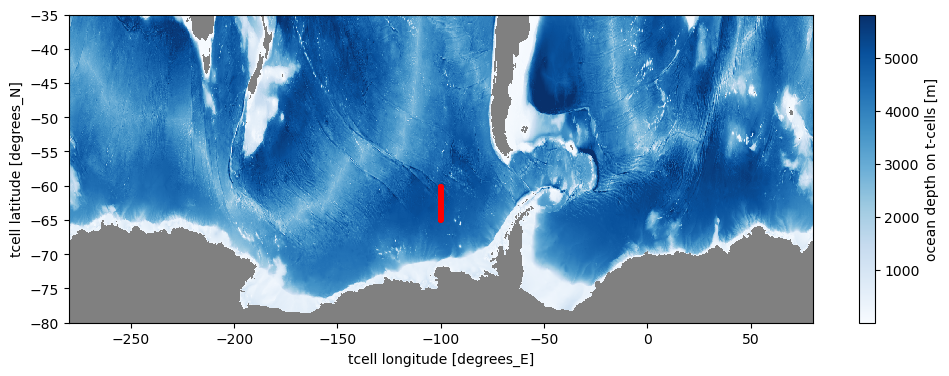

In [14]:
fig = plt.figure(figsize=(12, 4))

ht.plot(cmap='Blues')
plt.scatter(lons, lats, s=5, c='r')
plt.ylim([-80, -35]);

ax = plt.gca()
ax.set_facecolor('gray')

We can now advect these particles with Parcels. We'll do this using 4th order Runge-Kutta in 2D. In this example, we'll integrate the particle positions for only 50 days to keep it simple. This may take a few minutes depending on the resources you're using. Feel free to change the total length of the run as you like. 

In [15]:
warnings.filterwarnings("ignore", category=FutureWarning, message=".*xarray will not decode timedelta values.*")

**Note**: This cell might take ~5 minutes.

In [16]:
%%time
# Set your output location: 
output_filename = 'TestParticles_2D.zarr'

# Set the file name and the time step of the outputs 
# (particle locations will be saved every 2 days in this example). 
# If you're running long simulations, consider reducing this output timestep to 5 or 10 days to save storage and file space.  
output_file = pset.ParticleFile(name=output_directory / output_filename, 
                                outputdt=timedelta(days=2)
                               ) 

kernels = [AdvectionRK4, # the 2D advection kernel (which defines how particles move) 
           periodicBC,
           checkOutOfBounds ]

pset.execute(kernels, 
             runtime=timedelta(days=50),   # the total length of the run
             dt=timedelta(hours=2),        # the integration timestep of the kernels (generally, the smaller the better but this comes with a computational/time cost)
             output_file=output_file,      # the output file
            )      

INFO: Output files are stored in /scratch/jk72/ed7737/particle_tracking/TestParticles_2D.zarr.


INFO:parcels.tools.loggers:Output files are stored in /scratch/jk72/ed7737/particle_tracking/TestParticles_2D.zarr.


100%|██████████| 4320000.0/4320000.0 [04:58<00:00, 14452.99it/s]
CPU times: user 3min 13s, sys: 30.7 s, total: 3min 44s
Wall time: 5min 1s


Open the output file and plot the first 100 of these trajectories. 

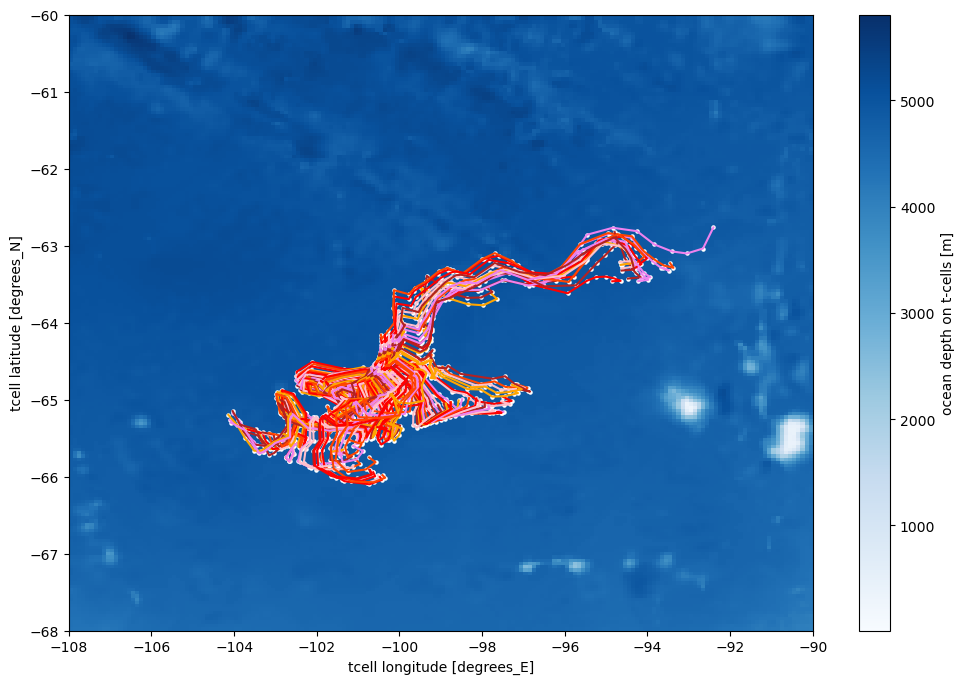

In [17]:
ds = xr.open_zarr(output_directory / output_filename)

fig = plt.figure(figsize=(12, 8))
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=["r", "pink", "violet", "firebrick", "orange", "orangered"])

ht.plot(cmap='Blues')

plt.plot(ds.lon[:100, :].T, ds.lat[:100, :].T)
plt.scatter(ds.lon[:100, :], ds.lat[:100, :], s=5, c='w')

plt.ylim([-68, -60])
plt.xlim([-108, -90]);

## 3D Advection with temperature and salinity sampling

Now we'll run an example in 3D and also sample and save temperature and salinity fields. 

In [18]:
import warnings, dask
warnings.simplefilter(action='ignore', category=dask.array.core.PerformanceWarning)

In [19]:
experiment = "01deg_jra55v13_ryf9091"

In [20]:
# define the file paths containing the daily U, V, W, temperature and salinity data
data_path = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091/'
ufiles = sorted(glob(data_path+'output19*/ocean/ocean_daily_3d_u_*.nc'))
vfiles = sorted(glob(data_path+'output19*/ocean/ocean_daily_3d_v_*.nc'))
wfiles = sorted(glob(data_path+'output19*/ocean/ocean_daily_3d_wt_*.nc'))
tfiles = sorted(glob(data_path+'output19*/ocean/ocean_daily_3d_temp_*.nc'))
sfiles = sorted(glob(data_path+'output19*/ocean/ocean_daily_3d_salt_*.nc'))

# Define a file which contains the model grid and coordinates that Parcels needs
# Note: We've already created this file under the 2D advection example, so here we're just defining a file path. 
mesh_mask = str(output_directory) + '/ocean.nc'

We now need to set up the Parcels `FieldSet`. For 3D advection we also need a vertical velocity field (`W`), and in this example we'll add temperature and salinity as well.

**Note:** Initialising the `FieldSet` can take some time depending on the domain and number of files you're feeding to Parcels. In this example, it should be quick. 

In [21]:
# Define a dictionary that tells Parcels where the U and V velocity data is,
# and where to find the coordinates. 
filenames = {'U': {'lon': mesh_mask, 'lat': mesh_mask, 'depth': mesh_mask, 'data': ufiles},
             'V': {'lon': mesh_mask, 'lat': mesh_mask, 'depth': mesh_mask, 'data': vfiles},
             'W': {'lon': mesh_mask, 'lat': mesh_mask, 'depth': mesh_mask, 'data': wfiles},
             'T': {'lon': mesh_mask, 'lat': mesh_mask, 'depth': mesh_mask, 'data': tfiles},
             'S': {'lon': mesh_mask, 'lat': mesh_mask, 'depth': mesh_mask, 'data': sfiles},
             }
# Now define a dictionary that specifies the `U, V` variable names as given in the netCDF files  
variables = {'U': 'u', 
             'V': 'v', 
             'W': 'wt', 
             'T': 'temp', 
             'S': 'salt', 
            }

# Define a dictionary to specify the U,V, W, T and S dimentions.
# All variables must have the same lat/lon/depth dimensions (even though the data doesn't).
# We can check that Parcels is using the right type of grid indexing and interpolation once we've created the fieldset
# For further reading, also see this tutorial on the Ocean Parcels website: 
# https://nbviewer.org/github/OceanParcels/parcels/blob/master/parcels/examples/documentation_indexing.ipynb
dimensions = {'U': {'lon': 'xu_ocean', 'lat': 'yu_ocean', 'depth': 'sw_ocean', 'time': 'time'},
              'V': {'lon': 'xu_ocean', 'lat': 'yu_ocean', 'depth': 'sw_ocean', 'time': 'time'},
              'W': {'lon': 'xu_ocean', 'lat': 'yu_ocean', 'depth': 'sw_ocean', 'time': 'time'},
              'T': {'lon': 'xu_ocean', 'lat': 'yu_ocean', 'depth': 'sw_ocean', 'time': 'time'},
              'S': {'lon': 'xu_ocean', 'lat': 'yu_ocean', 'depth': 'sw_ocean', 'time': 'time'},
             }

# Define the chunksizes
cs = {"U": {"lon": ("xu_ocean", 400), "lat": ("yu_ocean", 300), "depth": ("st_ocean", 75), "time": ("time", 1)}, 
      "V": {"lon": ("xu_ocean", 400), "lat": ("yu_ocean", 300), "depth": ("st_ocean", 75), "time": ("time", 1)},
      "W": {"lon": ("xt_ocean", 400), "lat": ("yt_ocean", 300), "depth": ("sw_ocean", 75), "time": ("time", 1)},
      "T": {"lon": ("xt_ocean", 400), "lat": ("yt_ocean", 300), "depth": ("st_ocean", 75), "time": ("time", 1)},
      "S": {"lon": ("xt_ocean", 400), "lat": ("yt_ocean", 300), "depth": ("st_ocean", 75), "time": ("time", 1)},
      }

# Read in the fieldset using the Parcels `FieldSet.from_mom5` function. 
fieldset = FieldSet.from_mom5(filenames, variables, dimensions,
                              mesh = 'spherical', 
                              chunksize = cs, 
                              tracer_interp_method = 'bgrid_tracer')

Check that the grid indexing and the interpolation methods have been correctly set by Parcels. MOM5 is a **B-grid** model. Anything other than **bgrid_velocity** and **bgrid_tracer** interpolation methods will give you incorrect results for this particular model/experiment. 

In [22]:
# check that the grid indexing type is correct for our model outpu (should be mom5, not nemo or any other type)
print(fieldset.U.gridindexingtype)
print(fieldset.V.gridindexingtype)
print(fieldset.W.gridindexingtype)
print(fieldset.T.gridindexingtype)
print(fieldset.S.gridindexingtype)

print(fieldset.U.interp_method)
print(fieldset.V.interp_method)
print(fieldset.W.interp_method)
print(fieldset.T.interp_method)
print(fieldset.S.interp_method)

mom5
mom5
mom5
mom5
mom5
bgrid_velocity
bgrid_velocity
bgrid_w_velocity
bgrid_tracer
bgrid_tracer


As for the 2D advection case, we need to tell Parcels that this fieldset is periodic in the zonal (east-west) direction. This is because, if the particle is close to the edge of the fieldset (but still in it), the advection scheme will need to interpolate velocities that may lay outside the fieldset domain. With the halo, we make sure the advection kernel can access these values.

In [23]:
fieldset.add_constant('halo_west', fieldset.U.grid.lon[0])
fieldset.add_constant('halo_east', fieldset.U.grid.lon[-1])
fieldset.add_periodic_halo(zonal=True)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/parcels/fieldset.py:1503: FieldSetWarning: The zonal halo is located at the east and west of current grid, with a dx = lon[1]-lon[0] between the last nodes of the original grid and the first ones of the halo. In your grid, lon[1]-lon[0] != lon[-1]-lon[-2]. Is the halo computed as you expect?
  grid.add_periodic_halo(zonal, meridional, halosize)


We now need to define a particle class that tells Parcels each particle has a temperature and salinity value associated with it. We also need to define a kernel to tell Parcels to sample the temperature and salinity fields at each integration timestep. 

In [24]:
# Parcels will automatically save the latitude, longitude, and depth to file at a timestep that 
# you specify (see cells below). This kernel tells Parcels to also save the temperature and salinity fields
# to file, along with the location data. 
class SampleParticle(JITParticle):
    thermo = Variable('thermo', dtype=np.float32, initial = 0.0)
    psal = Variable('psal', dtype=np.float32, initial = 0.0)

# Kernel to sample temperature and salinity (if you have fed them into your FieldSet above).
def SampleFields(particle, fieldset, time):
    particle.thermo = fieldset.T[time, particle.depth, particle.lat, particle.lon]
    particle.psal =   fieldset.S[time, particle.depth, particle.lat, particle.lon]

Now we can create the **Particle Set**. Well use the same particle set as in the 2D example but this time we'll initialise particles at 10m depth. This time you can see that `thermo` and `psal` have been added to the Particle Set. 

In [25]:
%%time

ht = cat[experiment].search(variable="ht").to_dask()

x1, x2 = -100.5, -100
y1, y2 = -60, -61

lons = ht.where((ht.yt_ocean<y1) & (ht.yt_ocean>y2) & (ht.xt_ocean<x2) & (ht.xt_ocean>x1), 
                drop=True).geolon_t.values.ravel()

lats = ht.where((ht.yt_ocean<y1) & (ht.yt_ocean>y2) & (ht.xt_ocean<x2) & (ht.xt_ocean>x1), 
                drop=True).geolat_t.values.ravel()

depths = np.full(len(lats), 10.)

pset = ParticleSet.from_list(fieldset=fieldset,      # the fields on which the particles are advected
                             pclass=SampleParticle,  # the type of particles we specified above with temp and salt added
                             lon=lons,               # a vector of release longitudes 
                             lat=lats,               # a vector of release latitudes
                             depth=depths,           # a vector of release depths 
                             time=0.)                # set time to start start time of daily velocity fields
pset

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/intake_esm/source.py:306: ConcatenationWarning: Attempting to concatenate datasets without valid dimension coordinates: retaining only first dataset. Request valid dimension coordinate to silence this warning.
  warnings.warn(


CPU times: user 7.96 s, sys: 2.25 s, total: 10.2 s
Wall time: 14.4 s


<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([-280.40, -280.30, -280.20, ...,  80.30,  80.40,  80.50], dtype=float32), lat=array([-81.09, -81.05, -81.00, ..., -32.75, -32.67, -32.59], dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  31276800.00,  31363200.00,  31449600.00]), time_origin=1950-01-01 12:00:00, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'mom5'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([-280.40, -280.30, -280.20, ...,  80.30,  80.40,  80.50], dtype=float32), lat=array([-81.09, -81.05, -81.00, ..., -32.75, -32.67, -32.59], dtype=float32), time=array([ 0.00,  86400.00,  172800.0

For the 3D advection we will integrate particles forward-in-time for 20 days to keep this example simple, but feel free to integrate longer! If you want really long integrations, or a large particle set, you will need to consider [submitting the analysis as a job on Gadi](https://cosima-recipes.readthedocs.io/en/latest/01-Cooking-Tutorials/02-Advanced/Submitting_analysis_jobs_to_gadi.html) or to some other HPC system of your liking.

**Note 1**: Generally you want to use a small integration timestep (`dt`). This is because, the larger the `dt`, the further particles will move in a single timestep and the more likely you are to get particles crossing ocean-land boundaries and 'beaching'. For example, in some Lagrangian applications it is common to use `dt` <= 15 minutes. However the choice of `dt` has to be balanced against the computational resources and the available simulation time. In this example, we'll use a `dt` of 1 hour to speed up the integration. If you want to integrate particles backwards-in-time, simple feed Parcels a negative `dt` value. 

**Note 2**: This 3D example may take some time (several minutes) depending on the resources you're using.

In [26]:
%%time
# Set your output location: 
output_filename = 'TestParticles_3D.zarr'

# the file name and the time step of the outputs 
# (particle locations will be saved every 2 days in this example)
output_file = pset.ParticleFile(name=output_directory / output_filename, 
                                outputdt=timedelta(days=2),
                               )

kernels = [AdvectionRK4_3D, periodicBC, SampleFields, checkOutOfBounds]

pset.execute(kernels, 
             runtime=timedelta(days=20),   # the total length of the run
             dt=timedelta(hours=1),        # the integration timestep of the kernel
             output_file=output_file,      # the output file
            )      


INFO: Output files are stored in /scratch/jk72/ed7737/particle_tracking/TestParticles_3D.zarr.


INFO:parcels.tools.loggers:Output files are stored in /scratch/jk72/ed7737/particle_tracking/TestParticles_3D.zarr.


100%|██████████| 1728000.0/1728000.0 [01:38<00:00, 17522.31it/s]
CPU times: user 50.8 s, sys: 13.6 s, total: 1min 4s
Wall time: 1min 40s


Open output file and scatter plot the first 100 of these trajectories, coloured by depth. 

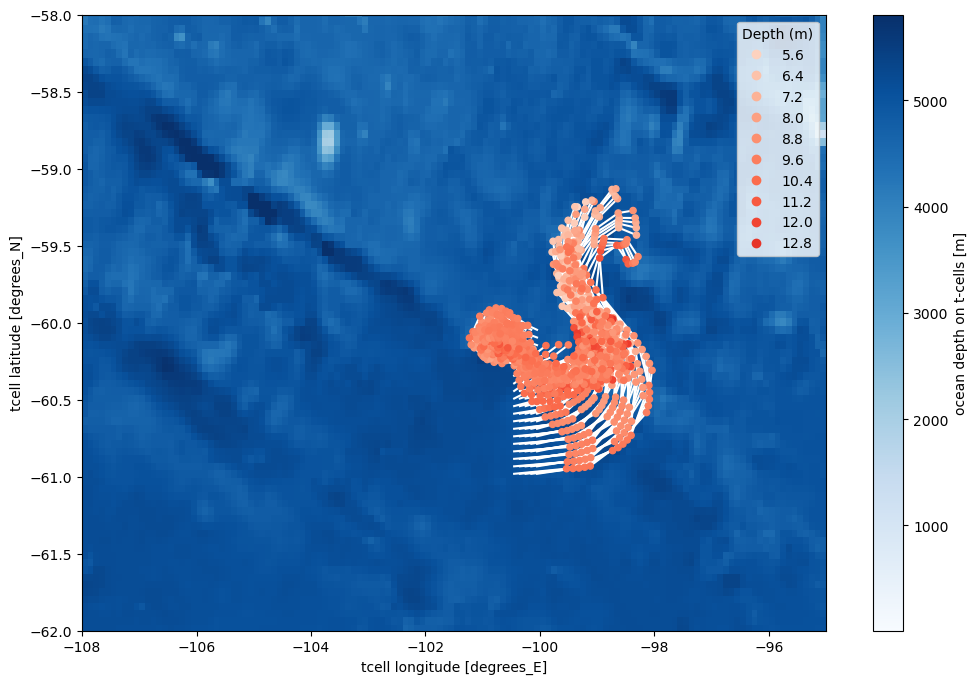

In [27]:
ds = xr.open_zarr(output_directory / output_filename)

fig = plt.figure(figsize=(12, 8))

ht['ht'].plot(cmap='Blues')

plt.plot(ds.lon[:100, :].T, ds.lat[:100, :].T, c='w', zorder=2)

cb = plt.scatter(ds.lon[:100, 1:], ds.lat[:100, 1:], c=ds.z[:100, 1:],
                 s=20, vmin=3, vmax=18, cmap='Reds', zorder=3)

plt.legend(*cb.legend_elements(num=10), loc="upper right", title="Depth (m)")

plt.ylim([-62, -58])
plt.xlim([-108, -95]);

For reference, this is how the output file is organised. 

In [28]:
ds

<xarray.Dataset> Size: 29kB
Dimensions:     (trajectory: 100, obs: 10)
Coordinates:
  * obs         (obs) int32 40B 0 1 2 3 4 5 6 7 8 9
  * trajectory  (trajectory) int64 800B 540 541 542 543 544 ... 636 637 638 639
Data variables:
    lat         (trajectory, obs) float32 4kB dask.array<chunksize=(100, 1), meta=np.ndarray>
    lon         (trajectory, obs) float32 4kB dask.array<chunksize=(100, 1), meta=np.ndarray>
    psal        (trajectory, obs) float32 4kB dask.array<chunksize=(100, 1), meta=np.ndarray>
    thermo      (trajectory, obs) float32 4kB dask.array<chunksize=(100, 1), meta=np.ndarray>
    time        (trajectory, obs) object 8kB dask.array<chunksize=(100, 1), meta=np.ndarray>
    z           (trajectory, obs) float32 4kB dask.array<chunksize=(100, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SampleParticleAdvectionRK4_3DperiodicBCSampleFiel...
    parcels_mesh:           spherical
    parcels_version:        3.1.4

## Convert the zarr data to netcdf [a crucial step!]

Parcels now uses [`Zarr`](https://zarr.dev) for its output. This creates very large numbers of files, which may overwhelm the inode quota for your project. When running particle tracking experiments, you should closely monitor you inode usage and once the simulation is complete, you should postprocess the output into either NetCDF format or use zipped `Zarr` storage format. You may find [this post on the ACCESS Hive](https://forum.access-hive.org.au/t/zarr-inodes/5496?u=edoddridge) and [this post on Stack Overflow](https://stackoverflow.com/questions/67635491/transform-zarr-directory-storage-to-zip-storage) helpful.

This example shows how to convert the zarr data to netcdf and how to delete the zarr files using the `rm` command. You should use `rm` on the command line to delete files when you have finished with them. **Do not use the ARE interface** to delete files - it doesn't actually delete them. Instead, those files are moved to a `.Trash*` folder in the project directory, where they still count towards the quotas for the project.

In [29]:
# Open the Zarr datastore files
ds = xr.open_zarr(output_directory / output_filename)

# Define the netcdf output filename 
netcdf_output_filename = output_filename[:-4] + 'nc'
print(netcdf_output_filename)

# Save to NetCDF
ds.to_netcdf(output_directory / netcdf_output_filename)

TestParticles_3D.nc


## Remove original zarr files



<div class="alert alert-block alert-warning">
<b>Caution:</b> Run this from the command line and be very careful about specifying the correct path
</div>

```
rm -r /path/to/zarr/files/TestParticles_2D.zarr
rm -r /path/to/zarr/files/TestParticles_3D.zarr
```

Files are currently stored in:

In [32]:
print(dir[0])

/scratch/jk72/ed7737/particle_tracking


# Modifying this example to work with ACCESS-OM3

As a community, we are migrating to **ACCESS-OM3** which uses the **MOM6** ocean model. MOM6 uses an Arakawa C-grid (rather than the B-grid used in MOM5/ACCESS-OM2) and so requires code modifications from the examples given above, including:
- A different `FieldSet` method 
- Updated varible names and dimensions
- A new `mesh_mask` 



For now, we will use output stored from a panAntarctic experiment (`panant-01-zstar-ACCESSyr2`) which is stored here:  
`/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/`

**! Warning !** In future, this data will be migrated to this location: `/g/data/cj50/access-nri/mom6-panant/panant-01-zstar-ACCESSyr2/`

**Note:** MOM6 does not output a vertical velocity diagnostic. This means, at this stage, only 2D particle tracking can be run offline with MOM6/ACCESS-OM3 output. 

In [4]:
# define the file paths containing the daily U and V velocity data
data_path = '/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/'
uvfiles = sorted(glob(data_path+'output*/*.ocean_daily_z_*.nc'))

# for the sake of simplicity, we'll only use the first month of daily data in this example
uvfiles = uvfiles[:31]

# Define the mesh mask containing the grid coordinates
mesh_mask = uvfiles[0]

<div class="alert alert-block alert-warning">
<b>MOM6 FieldSet Warning: </b> In MOM6 the t-cell dimensions (h points) have length 845 in the y direction and 3600 in the x direction, while the u-cell (q nodes) have length 846 and 3601. Parcels will complain about this mis-match. A work around is to restrict the lat and lon range to 845 and 3600 as in the code below. However, this causes problems with the periodic Halo construction and might not be the correct approach. <b>Use with caution!</b>
</div>

In [5]:
filenames = {"U": {"lon": mesh_mask, "lat": mesh_mask, "depth": mesh_mask, "data": uvfiles},
             "V": {"lon": mesh_mask, "lat": mesh_mask, "depth": mesh_mask, "data": uvfiles},
            }

variables = {"U": "uo", "V": "vo"}

# Note that all variables should be defined on the same dimension for a C-grid
# Parcels deals with the staggered velocities under the hood in it's interpolation.
# see more here: https://docs.oceanparcels.org/en/latest/examples/documentation_indexing.html
# or here: https://docs.parcels-code.org/en/latest/examples/tutorial_nemo_3D.html
c_grid_dimensions = {"lon": "xq",
                     "lat": "yq",
                     "depth": "z_l_sub01",
                     "time": "time",}

dimensions = {'U': c_grid_dimensions,
              'V': c_grid_dimensions,}


# NOTE: The t-cell dimensions (h points) have length 845 in the y and 3600 in x
# while the u-cell (q nodes) have length 846 and 3601 
# Parcels will complain about this mis-match. A work around is to restrict the 
# lat and lon range to 845 and 3600 as below. However, this might not be the correct 
# approach. Use with caution!
indices = {'lat': range(0, 845), 'lon': range(0, 3600)}

# You could also use the from_nemo FieldSet method, since Nemo 
# is a C-grid model with the same u/v indexing as MOM6 
# (see https://docs.oceanparcels.org/en/latest/examples/documentation_indexing.html) 
fieldset = FieldSet.from_c_grid_dataset(filenames, variables, dimensions, indices)


/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/parcels/fieldfilebuffer.py:59: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  self.dataset = xr.open_dataset(str(self.filename), decode_cf=True, engine=self.netcdf_engine)
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.08/lib/python3.11/site-packages/parcels/fieldfilebuffer.py:59: FutureWarning: In a future version, xarray will not decode timedelta values based on 

In [6]:
print(fieldset.U.gridindexingtype)
print(fieldset.V.gridindexingtype)

print(fieldset.U.interp_method)
print(fieldset.V.interp_method)

nemo
nemo
cgrid_velocity
cgrid_velocity


Define the Particle Set as for the MOM5 example. 

In [7]:
file = '/g/data/ol01/outputs/mom6-panan/panant-01-zstar-ACCESSyr2/output049/20050301.ocean_static.nc'
bathymetry = xr.open_dataset(file)

x1, x2 = -100.5, -100
y1, y2 = -60, -65

lons = bathymetry.where((bathymetry.yh<y1) & (bathymetry.yh>y2) & (bathymetry.xh<x2) & (bathymetry.xh>x1), 
                drop=True).geolon.values.ravel()
lats = bathymetry.where((bathymetry.yh<y1) & (bathymetry.yh>y2) & (bathymetry.xh<x2) & (bathymetry.xh>x1), 
                drop=True).geolat.values.ravel()
depths = np.full(len(lats), 1.)

pset = ParticleSet.from_list(fieldset=fieldset,   # the fields on which the particles are advected
                             pclass=JITParticle,  # the type of particles (JITParticle or ScipyParticle)
                             lon=lons,            # a vector of release longitudes 
                             lat=lats,            # a vector of release latitudes
                             depth=depths,        # a vector of release depths 
                             time=0.,             # set time to start start time of daily velocity fields
                             lonlatdepth_dtype=np.float32)             
pset

<ParticleSet>
    fieldset   :
        <FieldSet>
            fields:
                <Field>
                    name            : 'U'
                    grid            : RectilinearZGrid(lon=array([-280.00, -279.90, -279.80, ...,  79.70,  79.80,  79.90], dtype=float32), lat=array([-81.13, -81.09, -81.05, ..., -37.34, -37.26, -37.18], dtype=float32), time=array([ 0.00,  86400.00,  172800.00, ...,  2419200.00,  2505600.00,  2592000.00]), time_origin=2000-01-01 12:00:00, mesh='spherical')
                    extrapolate time: False
                    time_periodic   : False
                    gridindexingtype: 'nemo'
                    to_write        : False
                <Field>
                    name            : 'V'
                    grid            : RectilinearZGrid(lon=array([-280.00, -279.90, -279.80, ...,  79.70,  79.80,  79.90], dtype=float32), lat=array([-81.13, -81.09, -81.05, ..., -37.34, -37.26, -37.18], dtype=float32), time=array([ 0.00,  86400.00,  172800.00, 

In [8]:
warnings.filterwarnings("ignore", category=FutureWarning, message=".*xarray will not decode timedelta values.*")

In [11]:
%%time
# Set your output location: 
output_filename = 'TestParticles_MOM6_2D_indices_2.zarr'

# Set the file name and the time step of the outputs 
# (particle locations will be saved every 2 days in this example). 
# If you're running long simulations, reduce this output timestep to 5 or 10 days (or longer!) to save storage and file space.  
output_file = pset.ParticleFile(name=output_directory / output_filename, 
                                outputdt=timedelta(days=1)
                               ) 

kernels = [AdvectionRK4] # the 2D advection kernel (which defines how particles move) 

pset.execute(kernels, 
             runtime=timedelta(days=4),    # the total length of the run
             dt=timedelta(hours=2),        # the integration timestep of the kernels (generally, the smaller the better but this comes with a computational/time cost)
             output_file=output_file,      # the output file
            )      

INFO: Output files are stored in /scratch/e14/hd4873/particle_tracking/TestParticles_MOM6_2D_indices_2.zarr.


INFO:parcels.tools.loggers:Output files are stored in /scratch/e14/hd4873/particle_tracking/TestParticles_MOM6_2D_indices_2.zarr.


100%|██████████| 345600.0/345600.0 [00:55<00:00, 6262.07it/s] 
CPU times: user 49.2 s, sys: 20.1 s, total: 1min 9s
Wall time: 57 s
